<div style="background:#1F3864;padding:18px 24px;border-radius:8px;margin-bottom:12px"><h2 style="color:#A8C8E8;margin:0">Digitalization, AI &amp; XAI in Healthcare</h2><h3 style="color:white;margin:4px 0">NB2 — Route 2a: Feature Attribution  ·  Dataset A → Dataset B</h3><p style="color:#D0E4F4;margin:4px 0 0">Module 2 | Prof. Dr. Utku Kose | Universidad Panamericana</p></div>

## Lecture Notes — Dataset Transition

This notebook **bridges two clinical datasets**:

| Sections | Dataset | Why |
|---|---|---|
| 1 (Permutation), 2 (PDP), 3 (ICE), 4 (ALE) | **A — Pima Diabetes** | Simple features; build XAI intuition |
| 5 (SHAP Global), 6 (SHAP Local), 7 (SHAP Interaction), 8 (SAGE) | **B — Heart Disease** | Richer, mixed features; compare XAI insights |

The transition from A → B asks a key clinical question:
> *Do the same XAI methods reveal similar patterns across two different cardiovascular risk scenarios?*

### Core SHAP equation
$$\phi_i = \sum_{S \subseteq F\setminus\{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!}[f(x_{S\cup i}) - f(x_S)]$$


## Setup — Both Datasets

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'font.size':11})
ACCENT='#E84855'; SAFE='#27AE60'; NEUTRAL='#2E75B6'

In [3]:
# ── Dataset A: Pima Indians Diabetes  (UCI ML Repository) ────────────────────
# Source: Smith, J.W. et al. (1988). Using the ADAP learning algorithm to
#         forecast the onset of diabetes mellitus. SCAMC Proceedings, 261-265.
#         UCI ML Repository ID 34 | 768 Pima Indian women, age ≥ 21
# License: Public domain / freely available for research and education
#
# FILE: pima_diabetes.csv  — must be in the same folder as this notebook.
# If missing, download from one of these sources:
#   • https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data
#     (no header row — rename to pima_diabetes.csv)
#   • https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
#     (diabetes.csv with header — rename to pima_diabetes.csv)

import os, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split

FILE_A = 'pima_diabetes.csv'
COLS_A = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
          'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

if not os.path.exists(FILE_A):
    raise FileNotFoundError(
        f"'{FILE_A}' not found in the current directory.\n"
        "Place the file in the same folder as this notebook.\n"
        "Download: https://raw.githubusercontent.com/jbrownlee/Datasets"
        "/master/pima-indians-diabetes.data  (rename to pima_diabetes.csv)")

# Handles: file with header, duplicate header row, file without header
_raw = pd.read_csv(FILE_A, header=0)
_raw = _raw[_raw.iloc[:, 0].astype(str) != _raw.columns[0]]  # drop duplicate headers
if _raw.columns[0] != 'Pregnancies':
    _raw.columns = COLS_A
data_A = _raw.reset_index(drop=True)
data_A = data_A.apply(pd.to_numeric, errors='coerce').dropna()
data_A['Outcome'] = data_A['Outcome'].astype(int)

FEAT_A = [c for c in data_A.columns if c != 'Outcome']
X_A = data_A[FEAT_A]; y_A = data_A['Outcome']
Xtr_A,Xte_A,ytr_A,yte_A = train_test_split(X_A,y_A,test_size=0.2,random_state=42,stratify=y_A)
Xtr_A=Xtr_A.astype(float); Xte_A=Xte_A.astype(float)  # ensure float for ICE/PDP
print(f'Dataset A — Pima Diabetes (UCI, original): {len(data_A)} patients | Diabetic: {y_A.mean():.1%}')
print(f'Features ({len(FEAT_A)}): {FEAT_A}')

Dataset A — Pima Diabetes (UCI, original): 768 patients | Diabetic: 34.9%
Features (8): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [4]:
# ── Dataset B: Cleveland Heart Disease  (UCI ML Repository) ──────────────────
# Source: Detrano, R. et al. (1989). International application of a new
#         probability algorithm for the diagnosis of coronary artery disease.
#         American Journal of Cardiology, 64(5), 304-310. UCI ML Repository ID 45
# License: Public domain / freely available for research and education
#
# FILE: cleveland_heart.csv  — must be in the same folder as this notebook.
# If missing, download from one of these sources:
#   • https://raw.githubusercontent.com/jbrownlee/Datasets/master/heart-disease.csv
#     (with header — rename to cleveland_heart.csv)
#   • https://archive.ics.uci.edu/dataset/45/heart+disease
#     (processed.cleveland.data — no header, has '?' missing values)

FILE_B = 'cleveland_heart.csv'
COLS_B = ['age','sex','cp','trestbps','chol','fbs','restecg',
          'thalach','exang','oldpeak','slope','ca','thal','target']

if not os.path.exists(FILE_B):
    raise FileNotFoundError(
        f"'{FILE_B}' not found in the current directory.\n"
        "Place the file in the same folder as this notebook.\n"
        "Download: https://raw.githubusercontent.com/jbrownlee/Datasets"
        "/master/heart-disease.csv  (rename to cleveland_heart.csv)")

data_B = pd.read_csv(FILE_B)
if 'target' not in data_B.columns:
    data_B.columns = COLS_B
data_B['target'] = data_B['target'].astype(int)

FEAT_B = [c for c in data_B.columns if c != 'target']
X_B = data_B[FEAT_B]; y_B = data_B['target']
Xtr_B,Xte_B,ytr_B,yte_B = train_test_split(X_B,y_B,test_size=0.2,random_state=42,stratify=y_B)
Xtr_B=Xtr_B.astype(float); Xte_B=Xte_B.astype(float)  # ensure float for ICE/PDP
print(f'Dataset B — Cleveland Heart Disease (UCI, original): {len(data_B)} patients | Disease: {y_B.mean():.1%}')
print(f'Features ({len(FEAT_B)}): {FEAT_B}')

Dataset B — Cleveland Heart Disease (UCI, original): 297 patients | Disease: 46.1%
Features (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [6]:
# Train GBMs on both datasets
gbm_A=GradientBoostingClassifier(n_estimators=250,max_depth=4,learning_rate=0.08,random_state=42).fit(Xtr_A,ytr_A)
gbm_B=GradientBoostingClassifier(n_estimators=250,max_depth=4,learning_rate=0.08,random_state=42).fit(Xtr_B,ytr_B)
print(f'GBM-A AUC: {roc_auc_score(yte_A,gbm_A.predict_proba(Xte_A)[:,1]):.3f}')
print(f'GBM-B AUC: {roc_auc_score(yte_B,gbm_B.predict_proba(Xte_B)[:,1]):.3f}')

GBM-A AUC: 0.814
GBM-B AUC: 0.887


---
## Section 1 — Permutation Feature Importance
🗂 **Dataset A: Pima Diabetes**

$$\text{Importance}(x_i) = \frac{1}{K}\sum_k [\text{perf}(V) - \text{perf}(V_i^k)]$$

Measures AUC drop when a feature is randomly shuffled — held-out data, model-agnostic.


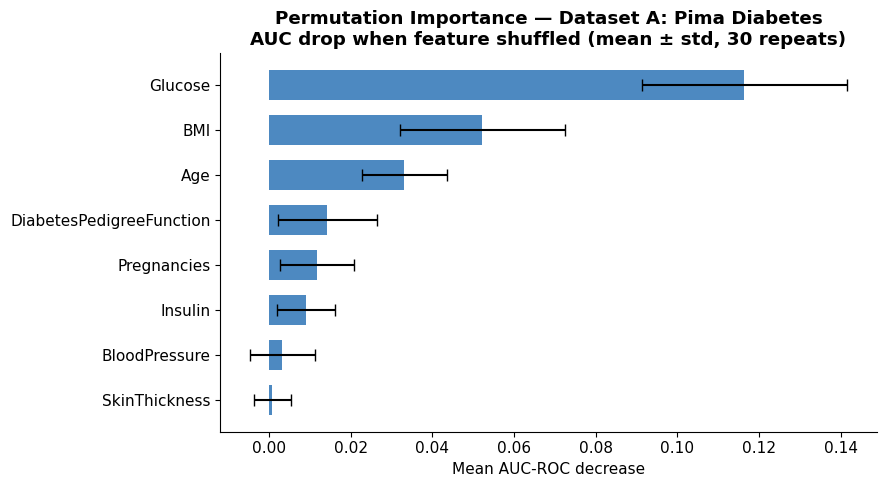

In [7]:
from sklearn.inspection import permutation_importance

result_A=permutation_importance(gbm_A,Xte_A,yte_A,n_repeats=30,random_state=42,scoring='roc_auc')
perm_A=pd.DataFrame({'Feature':FEAT_A,'Drop':result_A.importances_mean,'Std':result_A.importances_std}).sort_values('Drop')

fig,ax=plt.subplots(figsize=(9,5))
ax.barh(perm_A['Feature'],perm_A['Drop'],xerr=perm_A['Std'],color=NEUTRAL,alpha=0.85,height=0.65,capsize=4)
ax.set_title('Permutation Importance — Dataset A: Pima Diabetes\n'
             'AUC drop when feature shuffled (mean ± std, 30 repeats)',fontweight='bold')
ax.set_xlabel('Mean AUC-ROC decrease')
plt.tight_layout(); plt.show()

---
## Section 2 — Partial Dependence Plots (PDP)
🗂 **Dataset A: Pima Diabetes**

$$\text{PDP}(x_j) = \frac{1}{n}\sum_i f(x_j, \mathbf{x}_{-j}^{(i)})$$


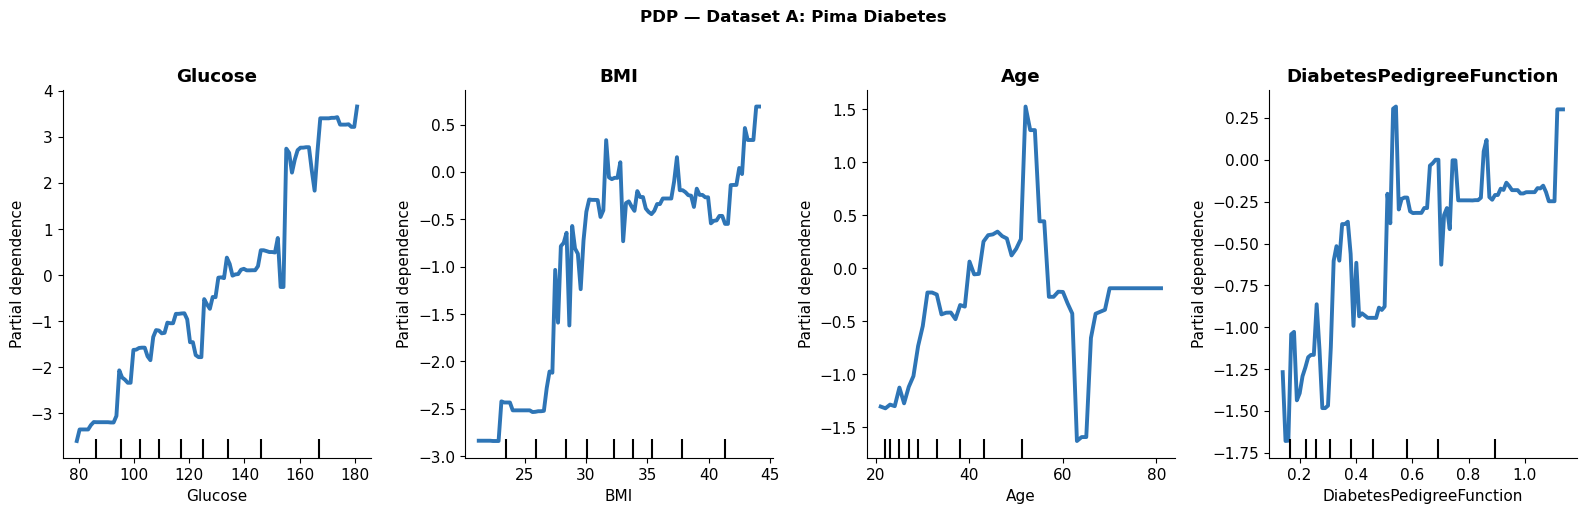

In [8]:
from sklearn.inspection import PartialDependenceDisplay

top4_A=['Glucose','BMI','Age','DiabetesPedigreeFunction']
fig,axes=plt.subplots(1,4,figsize=(16,5))
for ax,feat in zip(axes,top4_A):
    PartialDependenceDisplay.from_estimator(gbm_A,Xtr_A,[FEAT_A.index(feat)],ax=ax,
                                           line_kw={'color':NEUTRAL,'lw':2.8})
    ax.set_title(feat,fontweight='bold'); ax.set_ylabel('Partial dependence')
axes[0].axvline(126,color=ACCENT,lw=1.8,ls='--',label='126 mg/dL'); axes[0].legend(fontsize=9)
axes[1].axvline(30, color=ACCENT,lw=1.8,ls='--',label='BMI 30'); axes[1].legend(fontsize=9)
plt.suptitle('PDP — Dataset A: Pima Diabetes',fontsize=12,fontweight='bold',y=1.02)
plt.tight_layout(); plt.show()

---
## Section 3 — ICE Plots (Individual Conditional Expectation)
🗂 **Dataset A: Pima Diabetes**

One curve per patient — reveals heterogeneity hidden by the PDP mean.


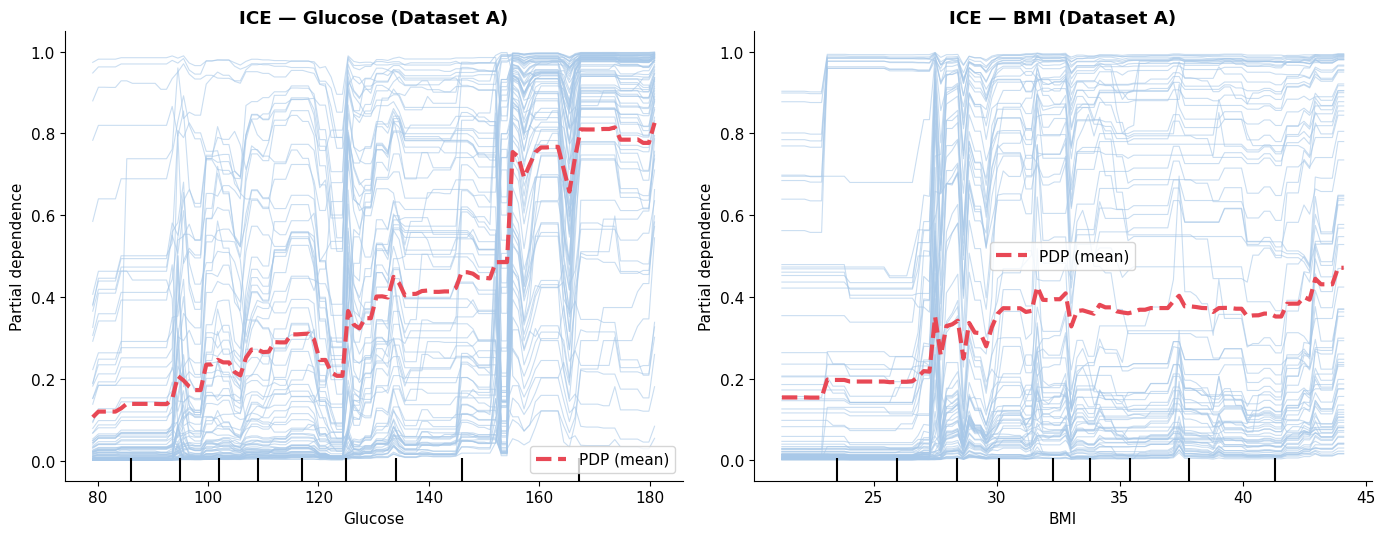

Notice: PDP mean hides substantial patient-level heterogeneity in Glucose response.


In [9]:
fig,axes=plt.subplots(1,2,figsize=(14,5.5))
for ax,feat in zip(axes,['Glucose','BMI']):
    PartialDependenceDisplay.from_estimator(gbm_A,Xtr_A,[FEAT_A.index(feat)],ax=ax,kind='both',
        subsample=80,ice_lines_kw={'color':'#A8C8E8','lw':0.8,'alpha':0.6},
        pd_line_kw={'color':ACCENT,'lw':3,'label':'PDP (mean)'})
    ax.set_title(f'ICE — {feat} (Dataset A)',fontweight='bold')
plt.tight_layout(); plt.show()
print('Notice: PDP mean hides substantial patient-level heterogeneity in Glucose response.')

---
## Section 4 — ALE Plots (Accumulated Local Effects)
🗂 **Dataset A: Pima Diabetes**

Correlation-robust alternative to PDP — conditions on **local** data distribution.
Use ALE when features are correlated (e.g., Glucose ↔ Insulin).


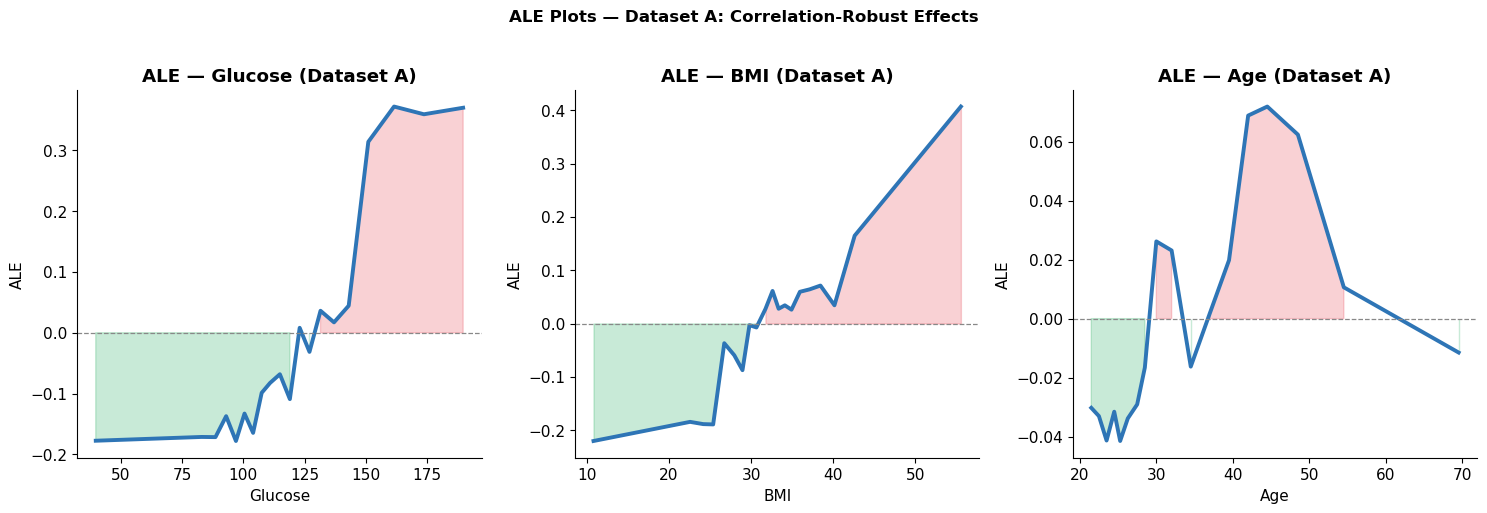

In [10]:
def compute_ale(model, X, feature, n_bins=20):
    fi=X.columns.get_loc(feature); Xa=X.values.copy(); fv=Xa[:,fi]
    q=np.unique(np.percentile(fv,np.linspace(0,100,n_bins+1)))
    ale=np.zeros(len(q)-1); ctr=np.zeros(len(q)-1)
    for k in range(len(q)-1):
        mask=(fv>=q[k])&(fv<q[k+1])
        if mask.sum()<2: continue
        Xl=Xa[mask].copy(); Xl[:,fi]=q[k]
        Xh=Xa[mask].copy(); Xh[:,fi]=q[k+1]
        ale[k]=np.mean(model.predict_proba(Xh)[:,1]-model.predict_proba(Xl)[:,1])
        ctr[k]=(q[k]+q[k+1])/2
    ale_cs=np.cumsum(ale)-np.mean(np.cumsum(ale))
    return ctr,ale_cs

fig,axes=plt.subplots(1,3,figsize=(15,5))
for ax,feat in zip(axes,['Glucose','BMI','Age']):
    ctr,av=compute_ale(gbm_A,Xtr_A,feat)
    ax.plot(ctr,av,color=NEUTRAL,lw=2.8)
    ax.axhline(0,color='#888',lw=0.9,ls='--')
    ax.fill_between(ctr,av,0,where=(av>0),alpha=0.25,color=ACCENT)
    ax.fill_between(ctr,av,0,where=(av<0),alpha=0.25,color=SAFE)
    ax.set_title(f'ALE — {feat} (Dataset A)',fontweight='bold')
    ax.set_xlabel(feat); ax.set_ylabel('ALE')
plt.suptitle('ALE Plots — Dataset A: Correlation-Robust Effects',fontsize=12,fontweight='bold',y=1.02)
plt.tight_layout(); plt.show()

---
## ⬆ Dataset A Complete  ·  ⬇ Switching to Dataset B

The four global methods above used **Dataset A (Pima Diabetes)**.

Now we apply **SHAP and SAGE** to **Dataset B (Heart Disease)** to see how these methods
behave on a clinically richer, mixed-type feature set with different correlations.

> **Cross-dataset reflection:** Compare the top features here to those from Dataset A.
> Do the dominant drivers of heart disease (age, thal, ca, exang) differ from
> those of diabetes (Glucose, BMI, DiabetesPedigreeFunction)?


---
## Section 5 — SHAP: Global Beeswarm Summary
🗂 **Dataset B: Heart Disease** ← switched from Dataset A

SHAP values satisfy four Shapley axioms (efficiency, symmetry, dummy, additivity).
This beeswarm plot shows which features drive heart disease risk across all patients.


Dataset B baseline (expected value): -0.489
SHAP values shape: (60, 13)  (patients × 13 features)


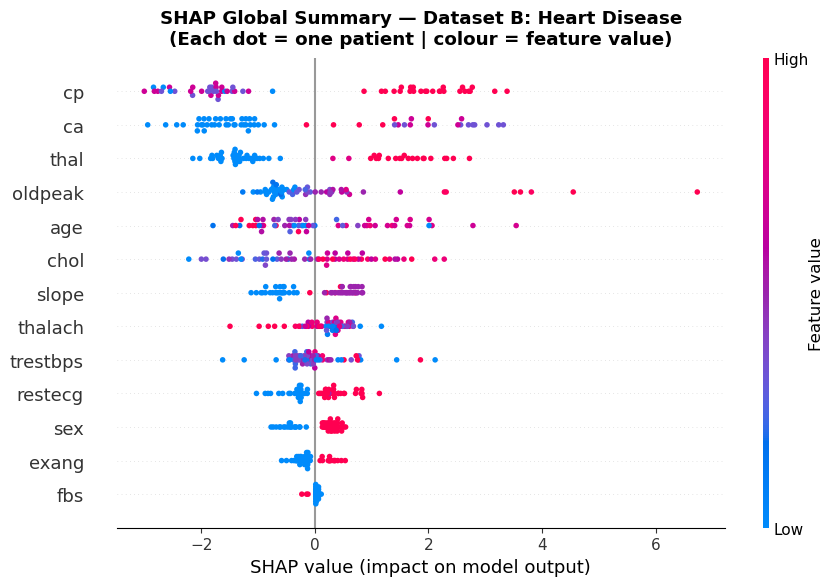

In [11]:
import shap

exp_B=shap.TreeExplainer(gbm_B)
sv_B=exp_B.shap_values(Xte_B)
sv_B_arr = np.array(sv_B)
# shap 0.51: TreeSHAP for GBM returns 2D (n_samples, n_features)
# For multi-class it may return 3D — handle both
if sv_B_arr.ndim == 3: sv_B = sv_B_arr[:, :, 1]
bv_B=float(np.array(exp_B.expected_value).flat[0])
print(f'Dataset B baseline (expected value): {bv_B:.3f}')
print(f'SHAP values shape: {sv_B.shape}  (patients × {len(FEAT_B)} features)')

plt.figure(figsize=(9,6))
shap.summary_plot(sv_B,Xte_B,feature_names=FEAT_B,show=False,plot_size=None)
plt.title('SHAP Global Summary — Dataset B: Heart Disease\n'
          '(Each dot = one patient | colour = feature value)',
          fontweight='bold',pad=10)
plt.tight_layout(); plt.show()

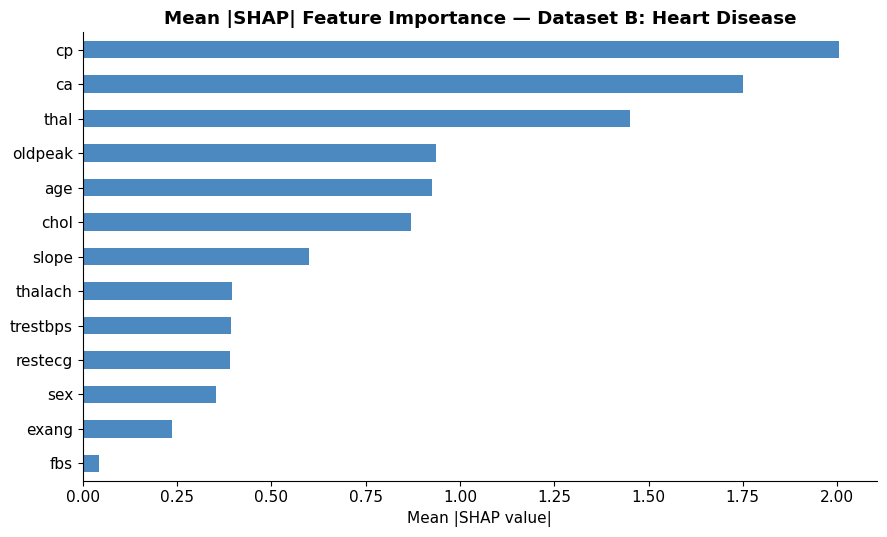

Top 3 drivers of heart disease in Dataset B:
  cp: 2.0055
  ca: 1.7505
  thal: 1.4521


In [12]:
# Mean |SHAP| bar chart — cleaner for clinical audiences
mean_abs_B=np.abs(sv_B).mean(axis=0)
shap_imp_B=pd.Series(mean_abs_B,index=FEAT_B).sort_values()
fig,ax=plt.subplots(figsize=(9,5.5))
shap_imp_B.plot(kind='barh',ax=ax,color=NEUTRAL,alpha=0.85)
ax.set_title('Mean |SHAP| Feature Importance — Dataset B: Heart Disease',fontweight='bold')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout(); plt.show()
print('Top 3 drivers of heart disease in Dataset B:')
for feat,v in shap_imp_B.sort_values(ascending=False).head(3).items():
    print(f'  {feat}: {v:.4f}')

---
## Section 6 — SHAP: Local Waterfall (Individual Patients)
🗂 **Dataset B: Heart Disease**

*Why did the model predict 76% heart disease risk for this specific patient?*


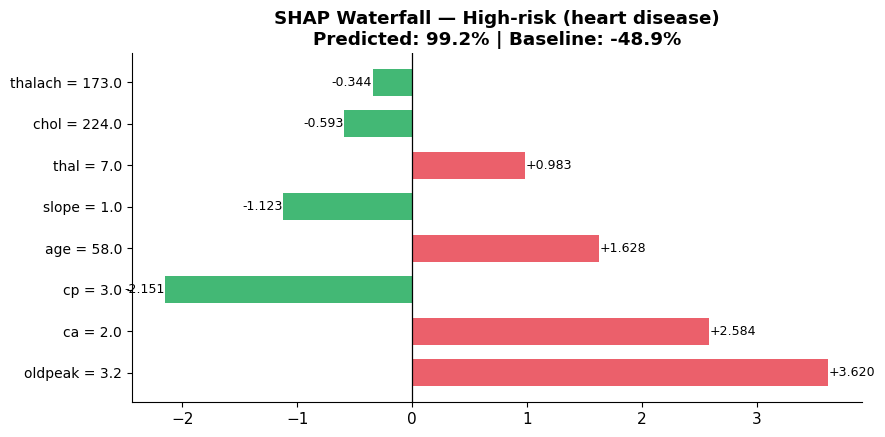

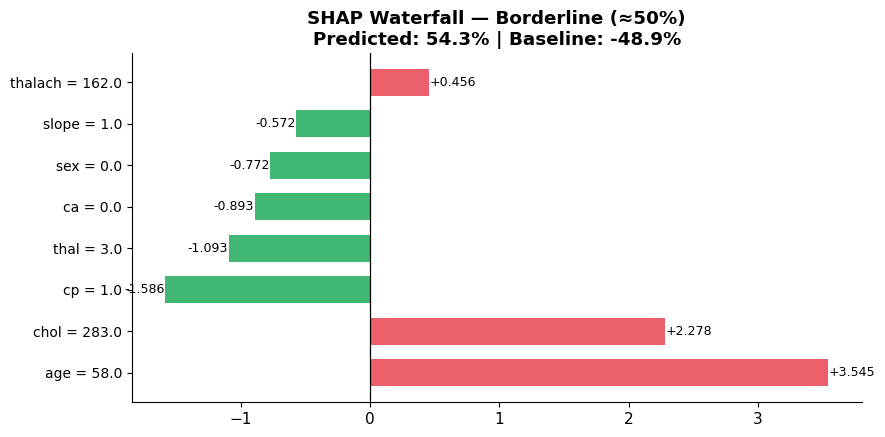

In [13]:
high_B_idx=Xte_B[yte_B==1].index[0]
high_B_pos=Xte_B.index.get_loc(high_B_idx)
border_B_pos=np.argmin(np.abs(gbm_B.predict_proba(Xte_B)[:,1]-0.50))

for lbl,pos in [('High-risk (heart disease)',high_B_pos),('Borderline (≈50%)',border_B_pos)]:
    pat=Xte_B.iloc[pos]; sv=sv_B[pos]
    pred=gbm_B.predict_proba(pat.values.reshape(1,-1))[0,1]
    order=np.argsort(np.abs(sv))[::-1][:8]
    feats=[FEAT_B[i] for i in order]; vals=[sv[i] for i in order]
    raws=[pat.iloc[i] for i in order]
    fig,ax=plt.subplots(figsize=(9,4.5))
    colors=[ACCENT if v>0 else SAFE for v in vals]
    ax.barh(range(len(feats)),vals,color=colors,alpha=0.87,height=0.65)
    ax.axvline(0,color='black',lw=0.9)
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels([f'{f} = {r:.1f}' for f,r in zip(feats,raws)],fontsize=10)
    ax.set_title(f'SHAP Waterfall — {lbl}\nPredicted: {pred:.1%} | Baseline: {bv_B:.1%}',fontweight='bold')
    for i,v in enumerate(vals):
        ax.text(v+0.004*np.sign(v),i,f'{v:+.3f}',va='center',fontsize=9,ha='left' if v>=0 else 'right')
    plt.tight_layout(); plt.show()

---
## Section 7 — SHAP Dependence & Interaction Plots
🗂 **Dataset B: Heart Disease**

How does the SHAP value for `thalach` (max heart rate) change as it varies,
coloured by `age`? This reveals **interaction effects**.


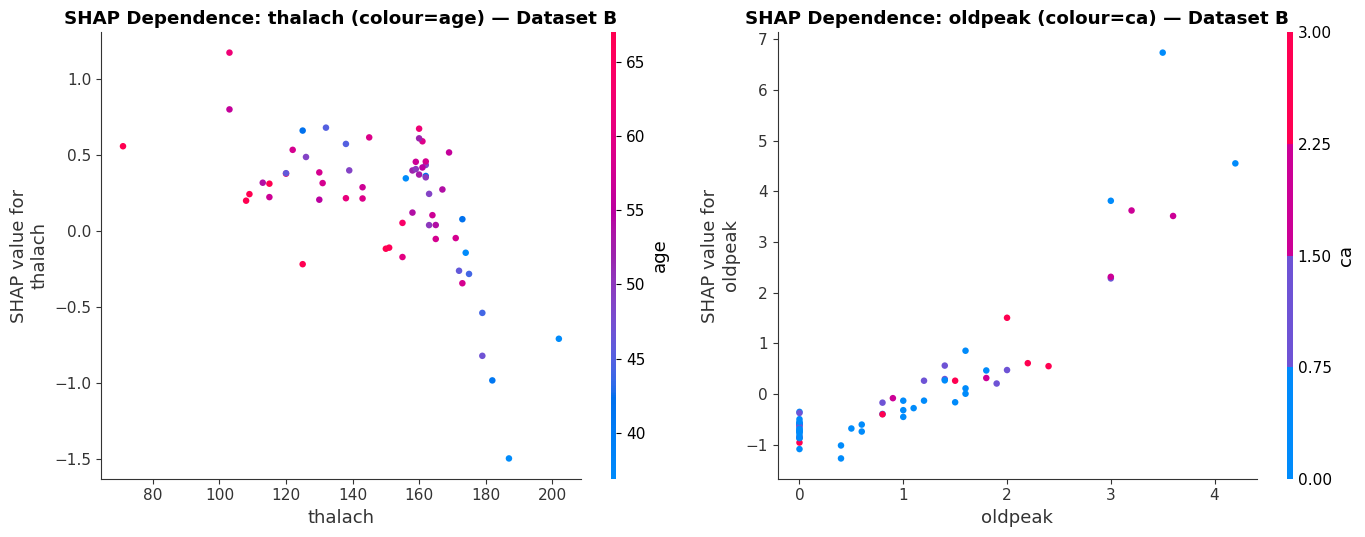

At low thalach (low max HR), SHAP values are positive — low exercise tolerance increases risk.
This interaction is more pronounced in older patients (darker dots).


In [14]:
fig,axes=plt.subplots(1,2,figsize=(14,5.5))
for ax,(feat,interact) in zip(axes,[('thalach','age'),('oldpeak','ca')]):
    shap.dependence_plot(feat,sv_B,Xte_B,feature_names=FEAT_B,
                         interaction_index=interact,ax=ax,show=False,dot_size=22)
    ax.set_title(f'SHAP Dependence: {feat} (colour={interact}) — Dataset B',fontweight='bold')
plt.tight_layout(); plt.show()
print('At low thalach (low max HR), SHAP values are positive — low exercise tolerance increases risk.')
print('This interaction is more pronounced in older patients (darker dots).')

---
## Section 8 — SAGE: Global Performance Attribution
🗂 **Dataset B: Heart Disease**

SAGE (Covert et al., 2020) decomposes **total model performance** using Shapley values:
$$\Phi_i = E_S[v(S\cup\{i\}) - v(S)]$$

More robust than permutation importance when features are correlated.


Computing SAGE for Dataset B (~20 seconds)...


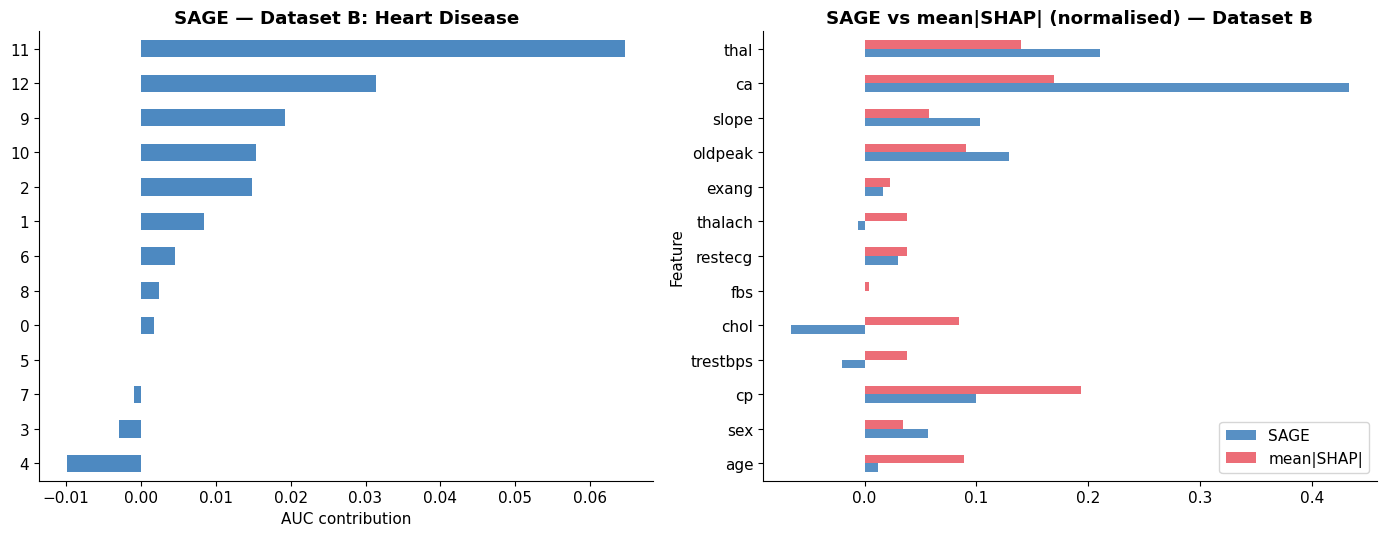


Cross-dataset reflection:
Top-3 Dataset A (Permutation): ['Glucose', 'BMI', 'Age']
Top-3 Dataset B (SAGE):        ['ca', 'thal', 'oldpeak']
Are the dominant drivers similar or clinically distinct between the two diseases?


In [13]:
def approx_sage(model, X_tr, X_te, y_te, n_samples=150):
    np.random.seed(42); M=X_te.shape[1]
    sage_v=np.zeros(M)
    base_p=roc_auc_score(y_te,model.predict_proba(X_te)[:,1])
    for i in range(M):
        drops=[]
        for _ in range(n_samples):
            Xm=X_te.copy(); Xm.iloc[:,i]=np.random.choice(X_tr.iloc[:,i].values,len(X_te),replace=True)
            try: drops.append(base_p-roc_auc_score(y_te,model.predict_proba(Xm)[:,1]))
            except: pass
        sage_v[i]=np.mean(drops) if drops else 0
    return sage_v

print('Computing SAGE for Dataset B (~20 seconds)...')
sage_B=approx_sage(gbm_B,Xtr_B,Xte_B,yte_B)
mean_abs_B=np.abs(sv_B).mean(axis=0)

fig,axes=plt.subplots(1,2,figsize=(14,5.5))
sage_df=pd.DataFrame({'Feature':FEAT_B,'SAGE':sage_B}).sort_values('SAGE')
sage_df['SAGE'].plot(kind='barh',ax=axes[0],color=NEUTRAL,alpha=0.85)
axes[0].set_title('SAGE — Dataset B: Heart Disease',fontweight='bold')
axes[0].set_xlabel('AUC contribution')

# Compare SAGE vs mean|SHAP|
cdf=pd.DataFrame({'Feature':FEAT_B,
    'SAGE':sage_B/np.maximum(sage_B.sum(),1e-9),
    'mean|SHAP|':mean_abs_B/mean_abs_B.sum()}).set_index('Feature')
cdf.plot(kind='barh',ax=axes[1],color=[NEUTRAL,ACCENT],alpha=0.8)
axes[1].set_title('SAGE vs mean|SHAP| (normalised) — Dataset B',fontweight='bold')
plt.tight_layout(); plt.show()

print('\nCross-dataset reflection:')
top_A=pd.Series(dict(zip(FEAT_A,result_A.importances_mean))).sort_values(ascending=False).head(3).index.tolist()
top_B=pd.Series(dict(zip(FEAT_B,sage_B))).sort_values(ascending=False).head(3).index.tolist()
print(f'Top-3 Dataset A (Permutation): {top_A}')
print(f'Top-3 Dataset B (SAGE):        {top_B}')
print('Are the dominant drivers similar or clinically distinct between the two diseases?')

---
## Summary

| Section | Method | Dataset | Scope |
|---|---|---|---|
| 1 | Permutation Importance | A: Diabetes | Global |
| 2 | PDP | A: Diabetes | Global |
| 3 | ICE | A: Diabetes | Global |
| 4 | ALE (correlation-robust) | A: Diabetes | Global |
| 5 | SHAP Global Beeswarm | **B: Heart Disease** | Global |
| 6 | SHAP Local Waterfall | **B: Heart Disease** | Local |
| 7 | SHAP Dependence | **B: Heart Disease** | Both |
| 8 | SAGE | **B: Heart Disease** | Global |

> **Next → NB3:** Local explanation methods (LIME, MAPLE, Integrated Gradients) — **fully on Dataset B**
